# 03 - Factor evaluation

Daily cross-sectional Spearman Rank IC between each final signal at close t and the forward return
from close t to close t+h (h = 1, 5, 10, 20). Within a period, the last h dates are dropped so no
label uses prices beyond the period. t-statistics use Newey-West standard errors (overlapping labels).
Research tables use train + validation; test-period IC is shown separately at the end.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
from IPython.display import Image, display
T, F, D = ROOT / "results/tables", ROOT / "results/figures", ROOT / "data/processed"
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 200)
from src.config import figure_relpath, table_relpath
def table(name, **kw):
    return pd.read_csv(T / table_relpath(name), **kw)
def fig(key, width=1100):
    display(Image(filename=str(F / figure_relpath(key)), width=width))

## Factor summary (train + validation, 5D horizon)

In [2]:
table("factor_summary_research", index_col=0)

,Window,Mean IC (5D),Median IC,IC Std,IC IR,Positive IC %,NW t-stat,Best Horizon (IC IR)
reversal,5,0.0160,0.0100,0.1678,0.0955,52.8781,3.3911,5D
momentum,120,0.0054,0.0142,0.2140,0.0252,52.7250,0.7617,1D
volatility,60,0.0046,-0.0024,0.2676,0.0170,49.4795,0.5184,1D


## Decay: mean IC and IC IR by horizon

In [3]:
table("factor_decay_research", index_col=0)

,1D,5D,10D,20D
factor,,,,
momentum,0.0077,0.0054,0.0030,-0.0029
reversal,0.0118,0.0160,0.0154,0.0140
volatility,0.0102,0.0046,0.0037,0.0035


In [4]:
table("factor_decay_icir_research", index_col=0)

,1D,5D,10D,20D
factor,,,,
momentum,0.0370,0.0252,0.0141,-0.0140
reversal,0.0662,0.0955,0.0939,0.0874
volatility,0.0378,0.0170,0.0142,0.0134


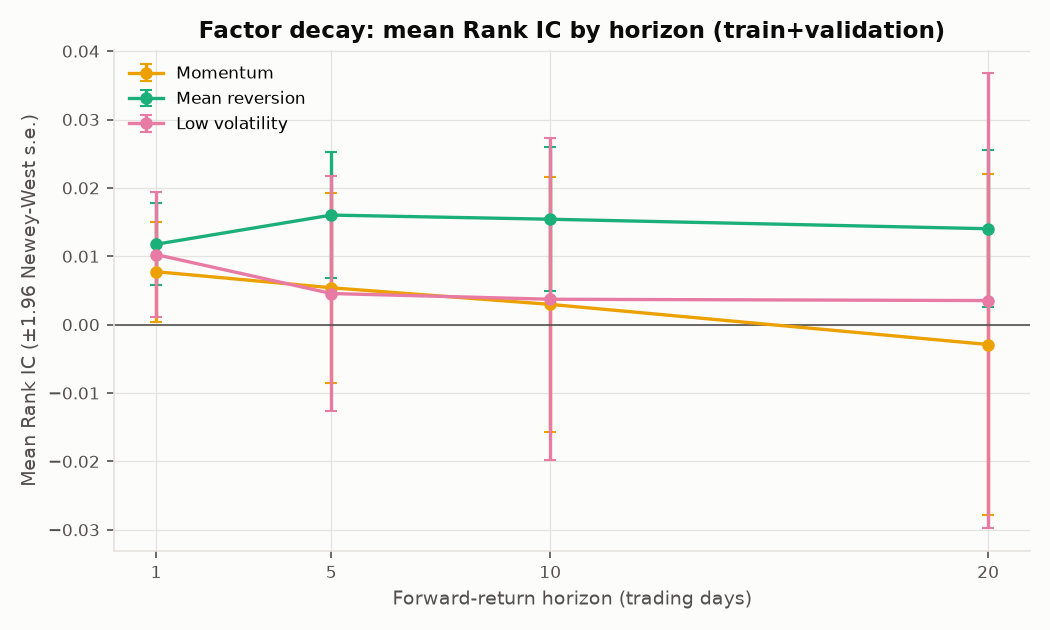

In [5]:
fig("factor_decay", 800)

## Robustness: is the IC driven by a few dates?

In [6]:
table("ic_robustness_research", index_col=0)

,trimmed_mean_ic,share_of_ic_sum_from_top_days,mean_ic,years_with_positive_mean_ic,years
reversal,0.0143,1.2493,0.0160,11,13
momentum,0.0087,3.9054,0.0054,6,13
volatility,0.0044,5.9770,0.0046,7,13


In [7]:
table("ic_by_year_research", index_col=0)

,reversal,momentum,volatility
date,,,
2007,0.0237,0.0767,0.0209
2008,0.0288,-0.0230,0.0456
2009,0.0212,-0.0046,-0.0352
2010,0.0195,-0.0230,-0.0287
2011,0.0316,0.0132,0.0381
2012,-0.0166,-0.0319,-0.0076
2013,0.0326,0.0184,-0.0226
2014,0.0221,-0.0058,0.0191
2015,-0.0006,0.0297,0.0382


In [8]:
# independent re-check of the 5D mean IC from the saved daily IC series
ic = pd.read_parquet(D / "ic_series_5d.parquet")
research = ic.loc["2007-01-01":"2019-12-31"].dropna(how="all")
print(research.mean().round(4))

reversal     0.0159
momentum     0.0052
volatility   0.0045
dtype: float64


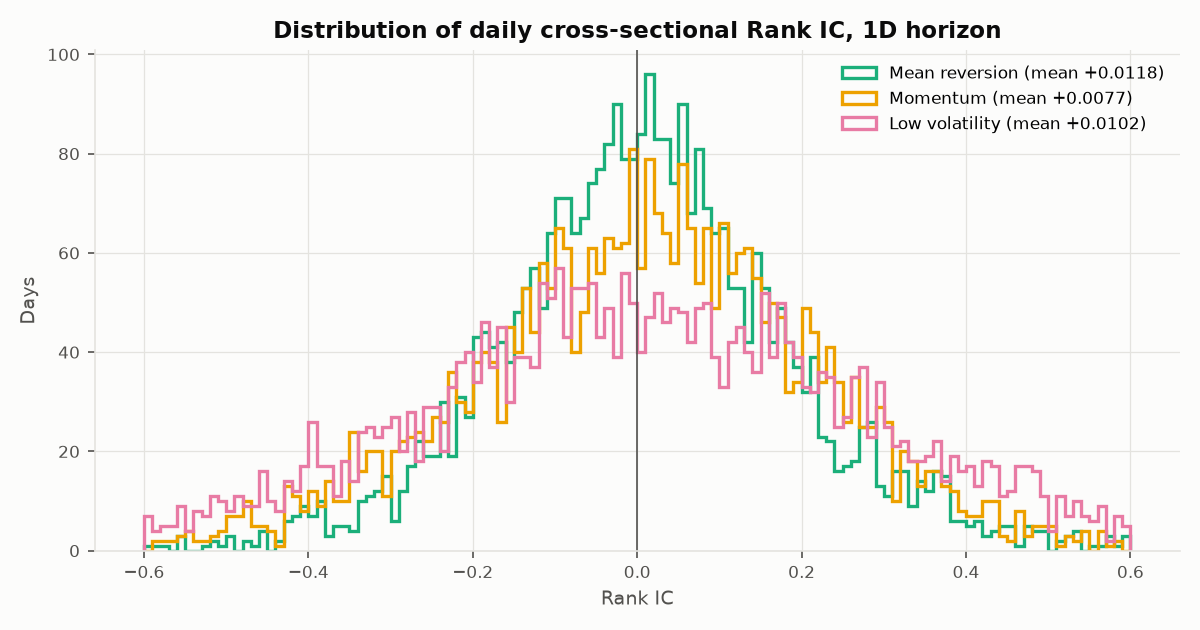

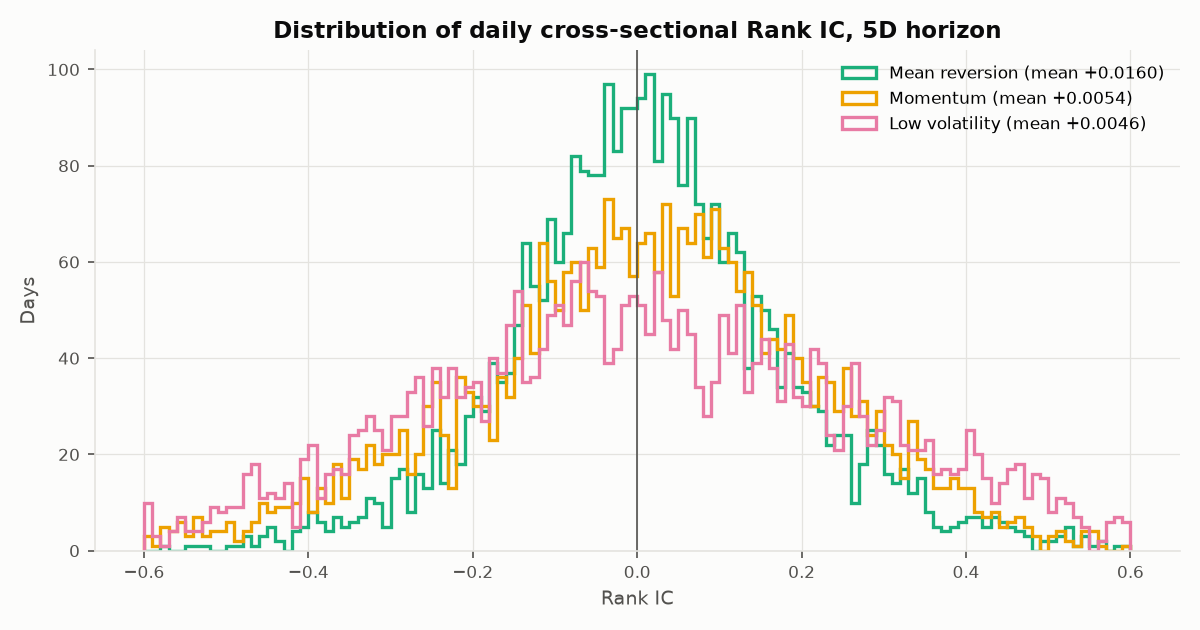

In [9]:
fig("ic_distribution_1d", 800); fig("ic_distribution_5d", 800)

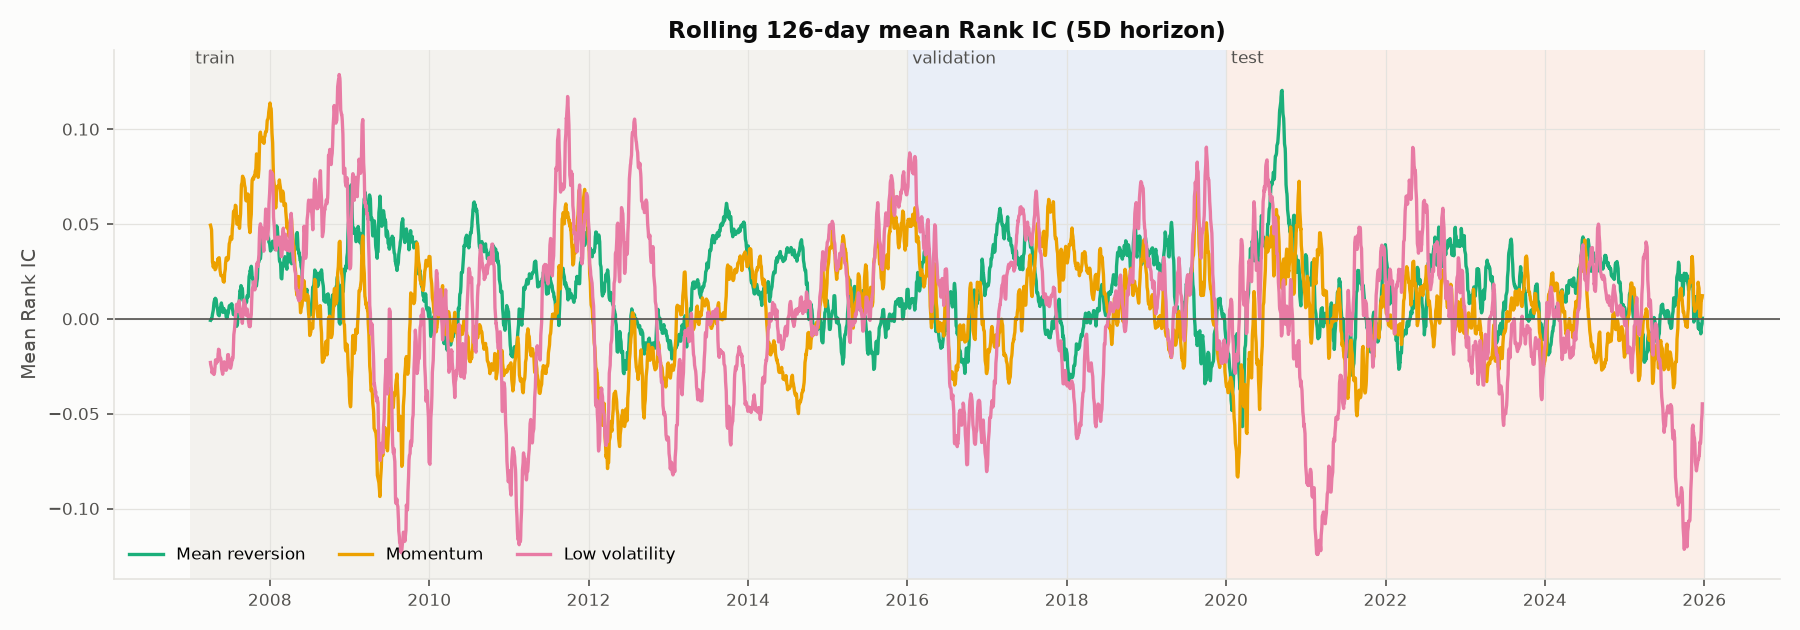

In [10]:
fig("ic_timeseries")

## Out-of-sample (test) factor IC

In [11]:
ict = table("ic_by_period_horizon")
ict[ict["period"].isin(["train", "validation", "test"])].pivot_table(index=["factor", "period"], columns="horizon", values="mean_ic")

horizon                   1       5       10      20
factor     period                                   
momentum   test       0.0101  0.0026 -0.0027 -0.0051
           train      0.0091  0.0052  0.0025 -0.0027
           validation 0.0050  0.0052  0.0022 -0.0084
reversal   test       0.0137  0.0149  0.0099  0.0062
           train      0.0139  0.0181  0.0134  0.0093
           validation 0.0068  0.0114  0.0202  0.0281
volatility test       0.0035 -0.0050 -0.0118 -0.0167
           train      0.0146  0.0071  0.0074  0.0071
           validation 0.0005 -0.0022 -0.0076 -0.0122

## Execution-aligned IC (signal at t, return from t+1 to t+6) for every signal, by period

In [12]:
table("signal_ic_execution_aligned", index_col=[0, 1])

mean_ic  median_ic  ic_std  ic_ir  pct_positive  t_stat_nw  n_days
period     signal                                                                          
train      ensemble       0.0119     0.0124  0.1212 0.0982        0.5445     2.4990    2259
           equal_weight   0.0117     0.0128  0.1142 0.1029        0.5507     2.6734    2259
           reversal       0.0065     0.0037  0.1116 0.0580        0.5144     1.6813    2259
           momentum       0.0080     0.0132  0.1522 0.0523        0.5343     1.2959    2259
           volatility     0.0098     0.0091  0.1077 0.0908        0.5334     2.3658    2259
validation ensemble       0.0123     0.0182  0.1505 0.0820        0.5550     1.4030    1000
           equal_weight   0.0132     0.0175  0.1441 0.0919        0.5540     1.5932    1000
           reversal       0.0152     0.0083  0.1293 0.1175        0.5260     2.2276    1000
           momentum       0.0078     0.0109  0.1762 0.0443        0.5350     0.7374    1000
           volatility     0.0056     0.0097  0.1190 0.0469        0.5310     0.8094    1000
test       ensemble       0.0096     0.0126  0.1474 0.0654        0.5346     1.4220    1502
           equal_weight   0.0107     0.0130  0.1509 0.0712        0.5360     1.5338    1502
           reversal       0.0051     0.0051  0.1459 0.0351        0.5193     0.8137    1502
           momentum       0.0057     0.0119  0.1870 0.0305        0.5260     0.6519    1502
           volatility     0.0102     0.0121  0.1187 0.0862        0.5419     1.8348    1502